# Visualizaciones tipo Data Science para reporte de ciberseguridad

Este notebook usa los CSV consolidados del análisis para generar gráficos orientados a:
- superficie de dependencias;
- severidad de vulnerabilidades;
- priorización;
- densidad de riesgo;
- patrones por vector de ataque;
- evidencia para el README y presentación oral.

In [1]:
from pathlib import Path

print("Carpeta actual:", Path.cwd())

for f in [
    "comparacion_priorizacion.csv",
    "resumen_sbom.csv",
    "resumen_grype.csv",
    "resumen_vectores.csv",
    "top_vulnerabilidades.csv"
]:
    print(f, "existe:", (Path.cwd() / f).exists())

Carpeta actual: /workspaces/produccion_software_emi305
comparacion_priorizacion.csv existe: False
resumen_sbom.csv existe: False
resumen_grype.csv existe: False
resumen_vectores.csv existe: False
top_vulnerabilidades.csv existe: False


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
DATA = BASE  / "data" / "results" / "resumen"

comparacion = pd.read_csv(DATA / "comparacion_priorizacion.csv")
resumen_sbom = pd.read_csv(DATA / "resumen_sbom.csv")
resumen_grype = pd.read_csv(DATA / "resumen_grype.csv")
resumen_vectores = pd.read_csv(DATA / "resumen_vectores.csv")
top_vulnerabilidades = pd.read_csv(DATA / "top_vulnerabilidades.csv")

pd.set_option("display.max_columns", 80)
display(comparacion.head())

,repo,paquetes_unicos,paquetes_totales,vulnerabilidades_grype,grype_critical,grype_high,grype_medium,grype_low,grype_negligible,grype_unknown,hallazgos_codeql,vulnerabilidades_criticas_altas,puntaje_prioridad
0,n8n,3363,5001,138.0,4.0,52.0,60.0,22.0,0.0,0.0,633.0,56.0,3097.63
1,ui,1596,4657,387.0,8.0,150.0,183.0,46.0,0.0,0.0,121.0,158.0,2028.96
2,developer-roadmap,980,1647,129.0,1.0,38.0,66.0,24.0,0.0,0.0,241.0,39.0,1409.80
3,stable-diffusion-webui,40,46,134.0,10.0,56.0,60.0,8.0,0.0,0.0,197.0,66.0,1404.40
4,dify,2001,2160,20.0,0.0,4.0,16.0,0.0,0.0,0.0,277.0,4.0,1200.01


## 1. Superficie de dependencias

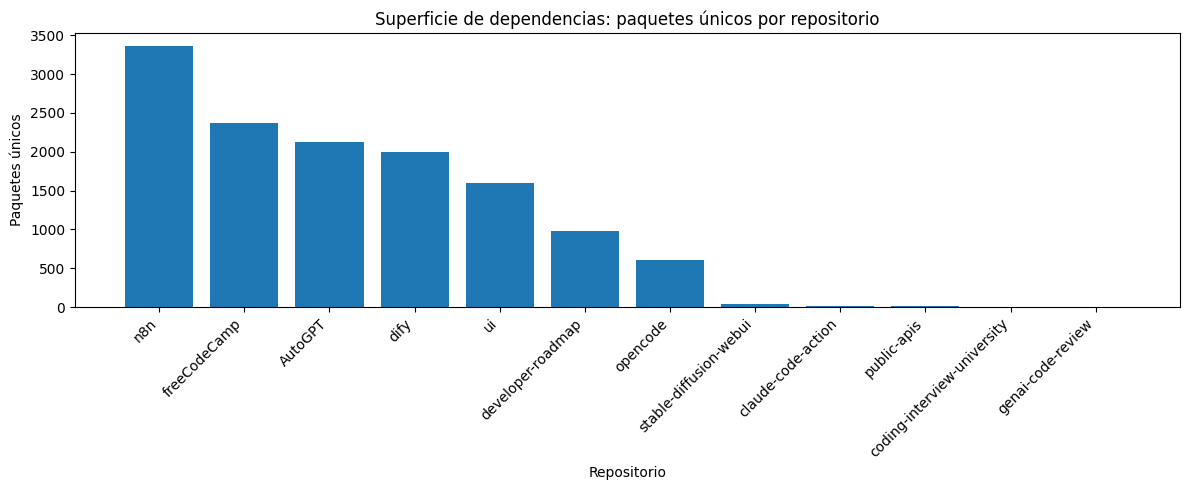

In [4]:
data = resumen_sbom.sort_values("paquetes_unicos", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(data["repo"], data["paquetes_unicos"])
plt.title("Superficie de dependencias: paquetes únicos por repositorio")
plt.xlabel("Repositorio")
plt.ylabel("Paquetes únicos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Vulnerabilidades Critical + High

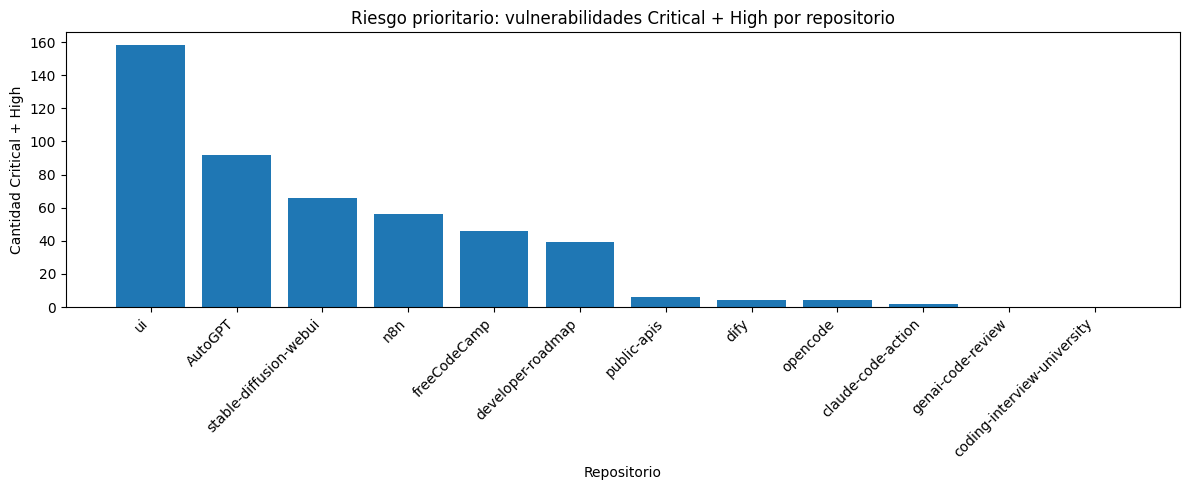

In [5]:
data = comparacion.sort_values("vulnerabilidades_criticas_altas", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(data["repo"], data["vulnerabilidades_criticas_altas"])
plt.title("Riesgo prioritario: vulnerabilidades Critical + High por repositorio")
plt.xlabel("Repositorio")
plt.ylabel("Cantidad Critical + High")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Puntaje de prioridad

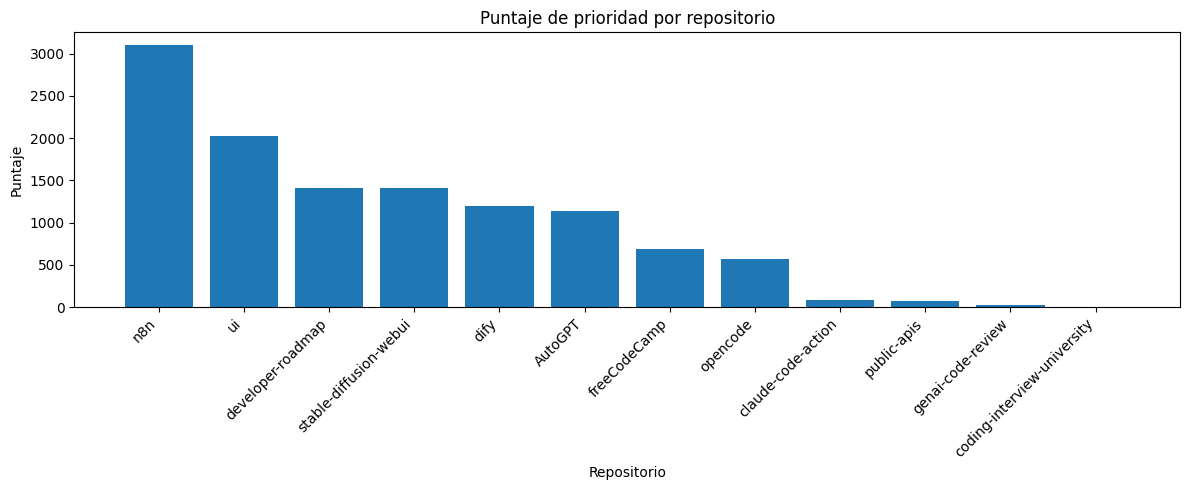

In [6]:
data = comparacion.sort_values("puntaje_prioridad", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(data["repo"], data["puntaje_prioridad"])
plt.title("Puntaje de prioridad por repositorio")
plt.xlabel("Repositorio")
plt.ylabel("Puntaje")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Relación entre dependencias y vulnerabilidades

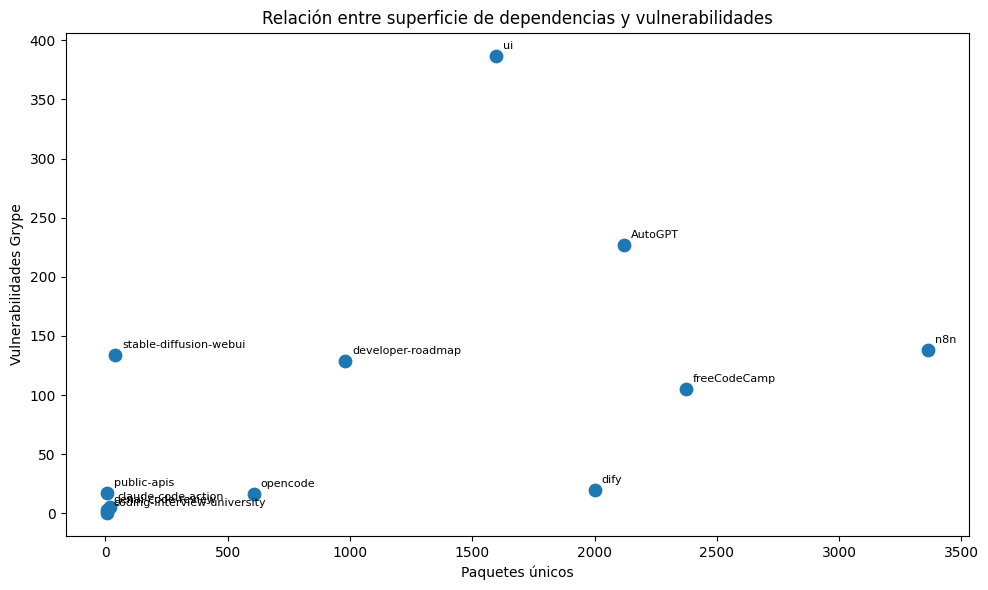

In [7]:
data = comparacion.copy()

plt.figure(figsize=(10, 6))
plt.scatter(data["paquetes_unicos"], data["vulnerabilidades_grype"], s=80)
for _, row in data.iterrows():
    plt.annotate(str(row["repo"]), (row["paquetes_unicos"], row["vulnerabilidades_grype"]), fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.title("Relación entre superficie de dependencias y vulnerabilidades")
plt.xlabel("Paquetes únicos")
plt.ylabel("Vulnerabilidades Grype")
plt.tight_layout()
plt.show()

## 5. Densidad de riesgo

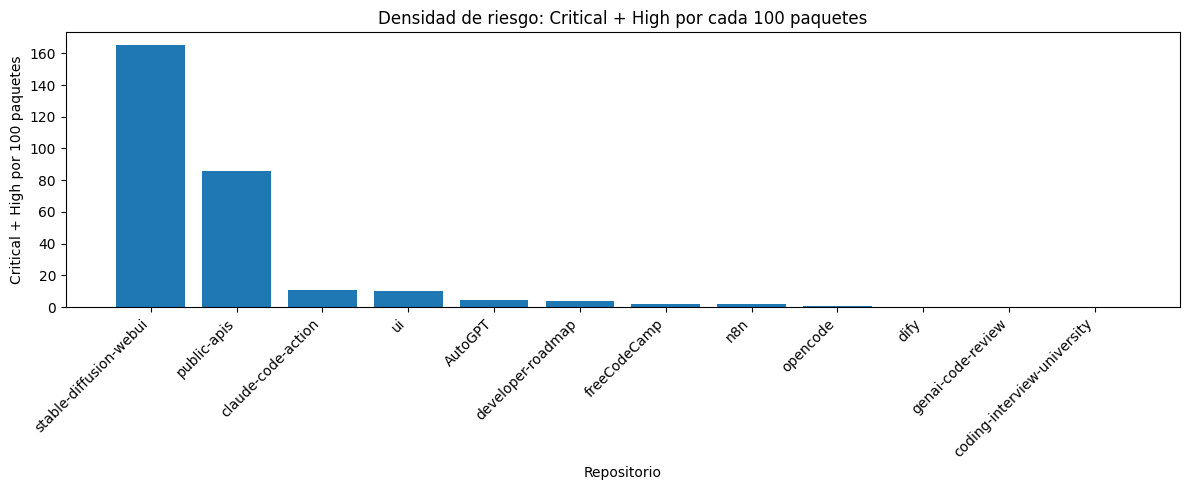

,repo,vulnerabilidades_criticas_altas,paquetes_unicos,densidad_ch_100
3,stable-diffusion-webui,66.0,40,165.000000
9,public-apis,6.0,7,85.714286
8,claude-code-action,2.0,19,10.526316
1,ui,158.0,1596,9.899749
5,AutoGPT,92.0,2122,4.335533
2,developer-roadmap,39.0,980,3.979592
6,freeCodeCamp,46.0,2374,1.937658
0,n8n,56.0,3363,1.665180
7,opencode,4.0,606,0.660066
4,dify,4.0,2001,0.199900


In [8]:
data = comparacion.copy()
data["densidad_ch_100"] = np.where(
    data["paquetes_unicos"] > 0,
    data["vulnerabilidades_criticas_altas"] / data["paquetes_unicos"] * 100,
    0
)
data = data.sort_values("densidad_ch_100", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(data["repo"], data["densidad_ch_100"])
plt.title("Densidad de riesgo: Critical + High por cada 100 paquetes")
plt.xlabel("Repositorio")
plt.ylabel("Critical + High por 100 paquetes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(data[["repo", "vulnerabilidades_criticas_altas", "paquetes_unicos", "densidad_ch_100"]])

## 6. Mapa de calor de severidades

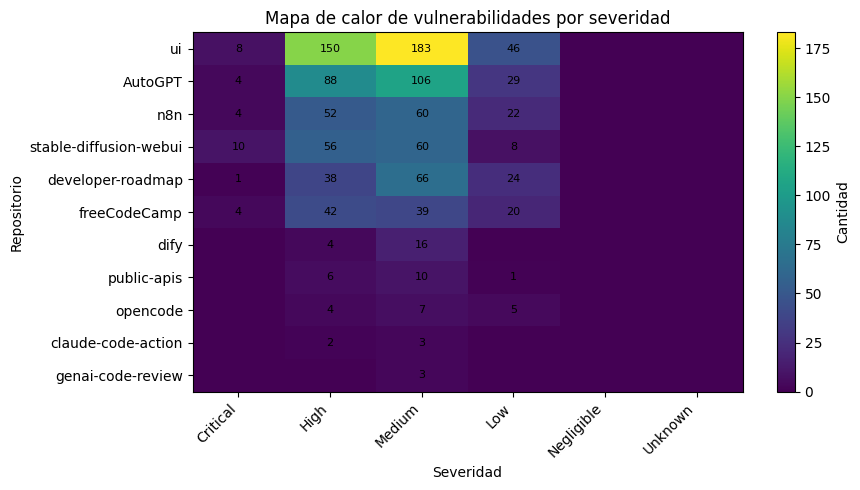

In [9]:
severity_cols = [c for c in ["Critical", "High", "Medium", "Low", "Negligible", "Unknown"] if c in resumen_grype.columns]
heat = resumen_grype.set_index("repo")[severity_cols].fillna(0)
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(9, max(5, len(heat)*0.45)))
plt.imshow(heat.values, aspect="auto")
plt.title("Mapa de calor de vulnerabilidades por severidad")
plt.xlabel("Severidad")
plt.ylabel("Repositorio")
plt.xticks(range(len(severity_cols)), severity_cols, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = int(heat.iloc[i, j])
        if val:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.colorbar(label="Cantidad")
plt.tight_layout()
plt.show()

## 7. Pareto de vulnerabilidades

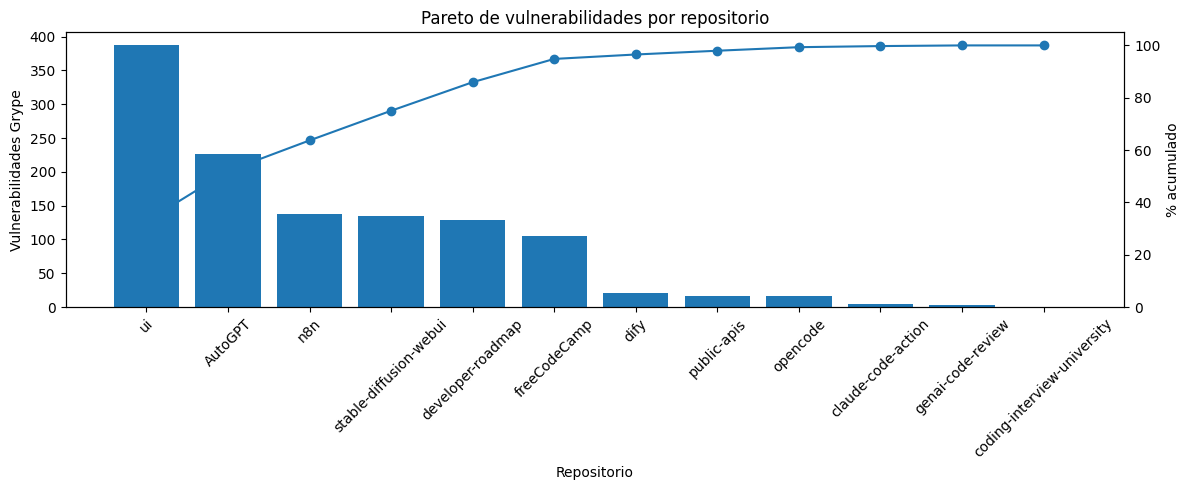

,repo,vulnerabilidades_grype,acumulado_pct
1,ui,387.0,32.768840
5,AutoGPT,227.0,51.989839
0,n8n,138.0,63.674852
3,stable-diffusion-webui,134.0,75.021169
2,developer-roadmap,129.0,85.944115
6,freeCodeCamp,105.0,94.834886
4,dify,20.0,96.528366
9,public-apis,17.0,97.967824
7,opencode,16.0,99.322608
8,claude-code-action,5.0,99.745978


In [10]:
data = comparacion.sort_values("vulnerabilidades_grype", ascending=False).copy()
data["acumulado_pct"] = data["vulnerabilidades_grype"].cumsum() / data["vulnerabilidades_grype"].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(data["repo"], data["vulnerabilidades_grype"])
ax1.set_xlabel("Repositorio")
ax1.set_ylabel("Vulnerabilidades Grype")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(data["repo"], data["acumulado_pct"], marker="o")
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 105)

plt.title("Pareto de vulnerabilidades por repositorio")
fig.tight_layout()
plt.show()

display(data[["repo", "vulnerabilidades_grype", "acumulado_pct"]])

## 8. Exposición con gráfico de burbujas

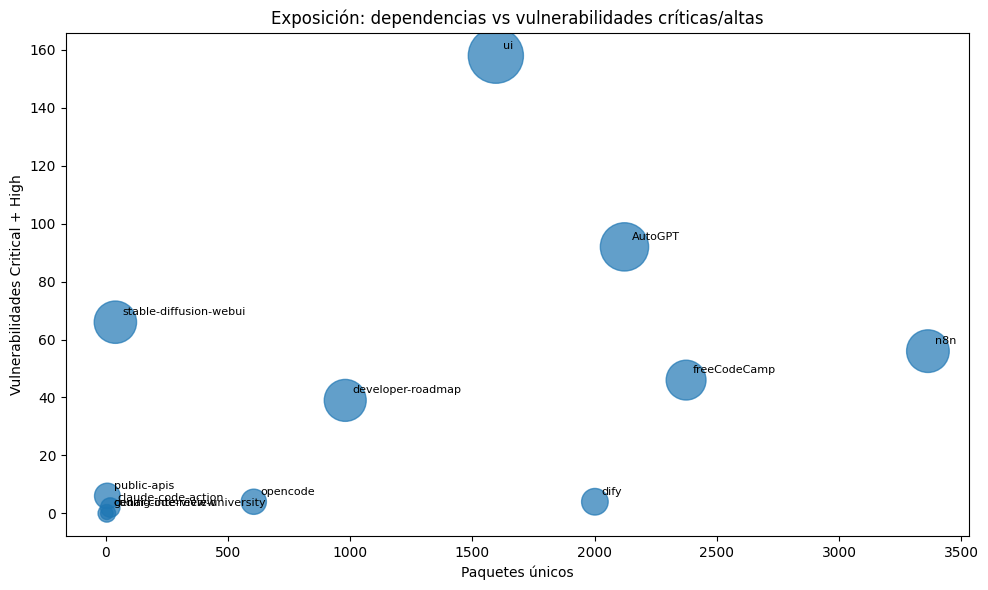

In [11]:
data = comparacion.copy()
sizes = np.sqrt(data["vulnerabilidades_grype"].fillna(0) + 1) * 80

plt.figure(figsize=(10, 6))
plt.scatter(data["paquetes_unicos"], data["vulnerabilidades_criticas_altas"], s=sizes, alpha=0.7)

for _, row in data.iterrows():
    plt.annotate(str(row["repo"]), (row["paquetes_unicos"], row["vulnerabilidades_criticas_altas"]), fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.title("Exposición: dependencias vs vulnerabilidades críticas/altas")
plt.xlabel("Paquetes únicos")
plt.ylabel("Vulnerabilidades Critical + High")
plt.tight_layout()
plt.show()

## 9. Hallazgos por vector de ataque

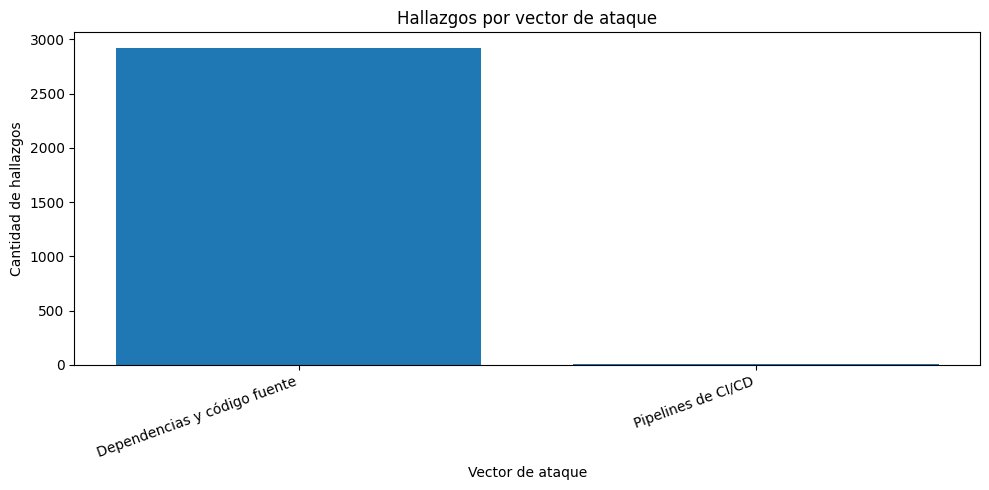

,vector_ataque,cantidad
0,Dependencias y código fuente,2918
1,Pipelines de CI/CD,3


In [12]:
data = resumen_vectores.groupby("vector_ataque")["cantidad"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(data.index.astype(str), data.values)
plt.title("Hallazgos por vector de ataque")
plt.xlabel("Vector de ataque")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(data.reset_index(name="cantidad"))

## 10. Paquetes más repetidos en vulnerabilidades priorizadas

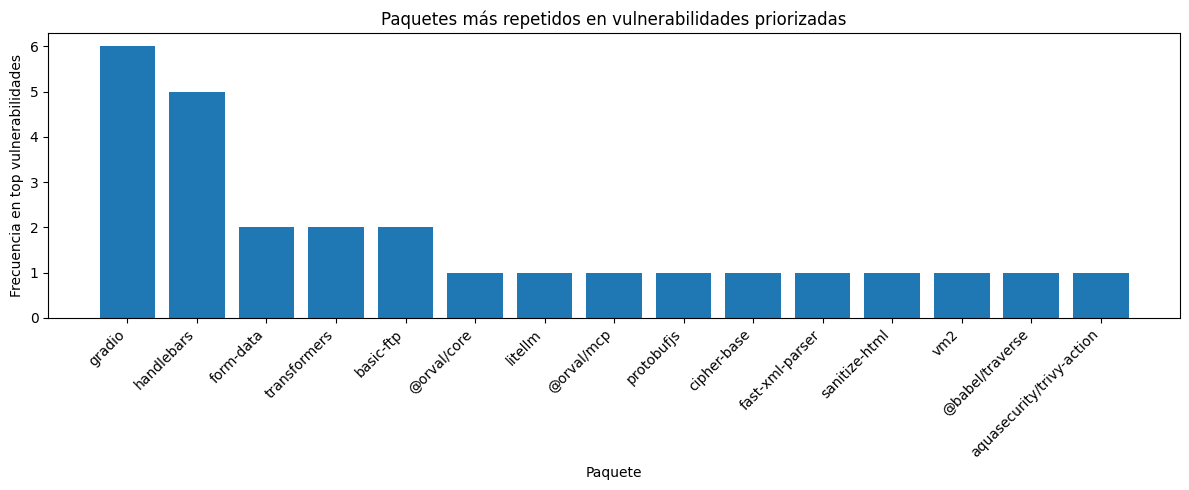

In [13]:
data = top_vulnerabilidades["paquete"].dropna().value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(data.index.astype(str), data.values)
plt.title("Paquetes más repetidos en vulnerabilidades priorizadas")
plt.xlabel("Paquete")
plt.ylabel("Frecuencia en top vulnerabilidades")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Cómo usar estas gráficas en el README

Recomendación:
- Usar 3 o 4 gráficas principales en el README.
- Dejar el resto como evidencia en `evidence/graficas/`.
- Para la presentación oral, usar máximo 4: superficie de dependencias, Critical/High, densidad de riesgo y Pareto.